In [1]:
from aircraft import Aircraft, AircraftPerformance
import math
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#seconds
ts_start = 0
ts_end = 550
time_delta = 1

In [3]:
# I am considering a Cessna 172 like aircraft.
# 140km/h = 39 m/s aprox.
# 3 degrees/sec - based on the Brazilian Air Traffic rules - please refer to ICA 100-12
# Assuming a burn rate of 0.00722 gallons per second (7 gallons per hour)
# 55 gallons of fuel
default_performance = AircraftPerformance(
    max_speed=38,
    max_turn_rate=math.pi/60,
    max_vertical_speed=3,
    fuel_burn_rate=0.00722,
    initial_fuel_level=55,
)

x_start = 0
y_start = 0
z_start = 300 #msl
heading_start = 0 # north / positive Y

# A straight lateral path isolates the vertical guidance behavior.
# The aircraft holds 300 m, climbs to 600 m, descends to 200 m,
# and finally climbs to 450 m.
route = [
    (0, 1000, 300),
    (0, 3000, 600),
    (0, 6000, 200),
    (0, 9000, 450),
]

acft = Aircraft(
    default_performance,
    x_start,
    y_start,
    z_start,
    heading_start,
    route=route,
)
sim_time = []
target_altitudes = []
waypoint_indices = []
for i in range(ts_start, ts_end, time_delta):
    acft.advance_step(time_delta)
    sim_time.append(i + time_delta)
    target_altitudes.append(acft.autopilot.active_waypoint[2])
    waypoint_indices.append(acft.autopilot.current_waypoint_index)


In [4]:
# Log entries expose named fields, such as x, z, and vertical_speed_delta.

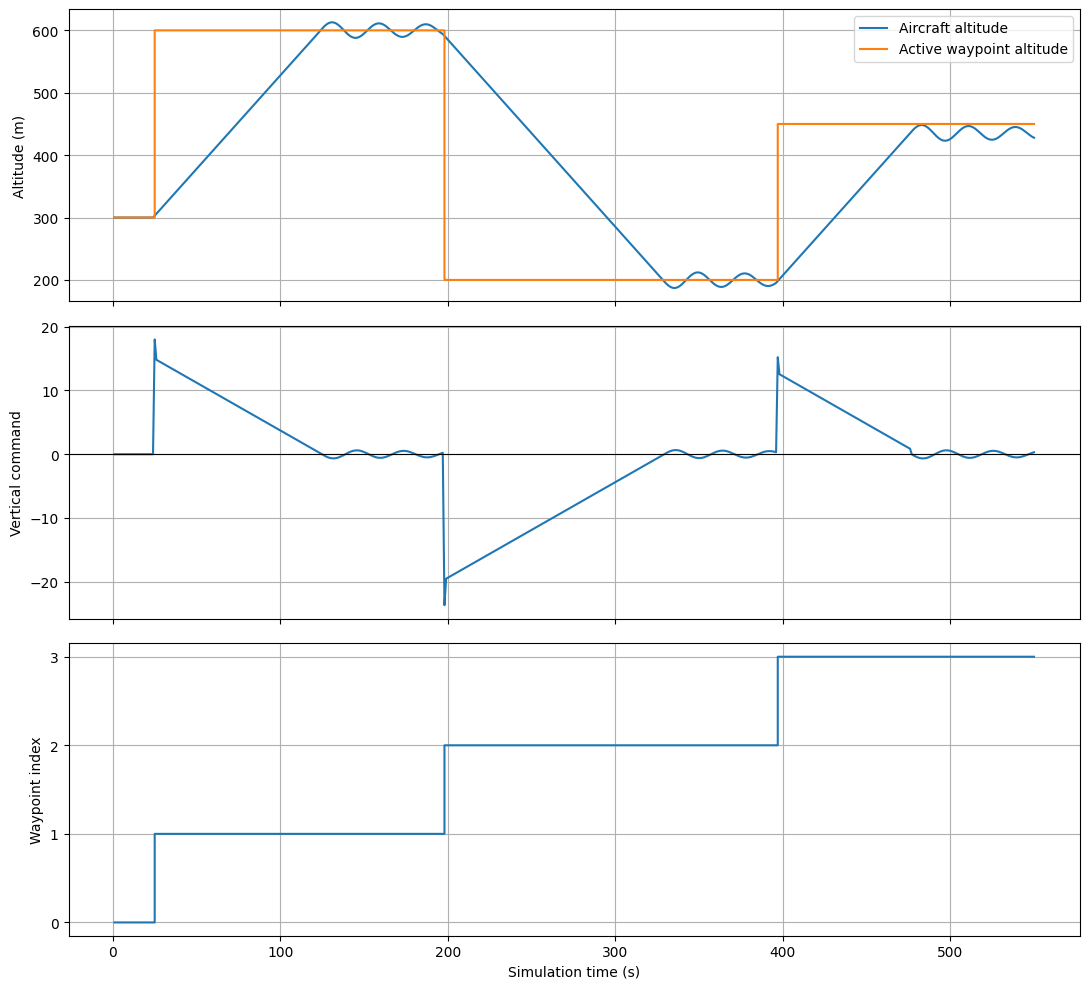

Route complete: True
Final altitude: 427.9 m


In [5]:
altitudes = [entry.z for entry in acft.log]
vertical_commands = [entry.vertical_speed_delta for entry in acft.log]

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
axes[0].plot(sim_time, altitudes, label="Aircraft altitude")
axes[0].step(sim_time, target_altitudes, where="post", label="Active waypoint altitude")
axes[0].set_ylabel("Altitude (m)")
axes[0].legend()
axes[0].grid()

axes[1].plot(sim_time, vertical_commands)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("Vertical command")
axes[1].grid()

axes[2].step(sim_time, waypoint_indices, where="post")
axes[2].set_ylabel("Waypoint index")
axes[2].set_xlabel("Simulation time (s)")
axes[2].set_yticks(range(len(route)))
axes[2].grid()

plt.tight_layout()
plt.show()

print(f"Route complete: {acft.autopilot.route_complete}")
print(f"Final altitude: {acft.z:.1f} m")